---
### 1 — Imports & Load Data

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
path = r"C:\Users\X1 YOGA\Documents\Data_Analytics_Portfolio\\"

mql = pd.read_csv(path + "olist_marketing_qualified_leads_dataset.csv")
deals = pd.read_csv(path + "olist_closed_deals_dataset.csv")

print("MQL shape:", mql.shape)
print("Deals shape:", deals.shape)

MQL shape: (8000, 4)
Deals shape: (842, 14)


---
### 2 — Peek at the Data

In [4]:
print("=== MQL COLUMNS ===")
print(mql.columns.tolist())
print("\n=== MQL FIRST 3 ROWS ===")
print(mql.head(3))

print("\n=== DEALS COLUMNS ===")
print(deals.columns.tolist())
print("\n=== DEALS FIRST 3 ROWS ===")
print(deals.head(3))

=== MQL COLUMNS ===
['mql_id', 'first_contact_date', 'landing_page_id', 'origin']

=== MQL FIRST 3 ROWS ===
                             mql_id first_contact_date  \
0  dac32acd4db4c29c230538b72f8dd87d         2018-02-01   
1  8c18d1de7f67e60dbd64e3c07d7e9d5d         2017-10-20   
2  b4bc852d233dfefc5131f593b538befa         2018-03-22   

                    landing_page_id          origin  
0  88740e65d5d6b056e0cda098e1ea6313          social  
1  007f9098284a86ee80ddeb25d53e0af8     paid_search  
2  a7982125ff7aa3b2054c6e44f9d28522  organic_search  

=== DEALS COLUMNS ===
['mql_id', 'seller_id', 'sdr_id', 'sr_id', 'won_date', 'business_segment', 'lead_type', 'lead_behaviour_profile', 'has_company', 'has_gtin', 'average_stock', 'business_type', 'declared_product_catalog_size', 'declared_monthly_revenue']

=== DEALS FIRST 3 ROWS ===
                             mql_id                         seller_id  \
0  5420aad7fec3549a85876ba1c529bd84  2c43fb513632d29b3b58df74816f1b06   
1  a555fb3

---
### 3 — Null Check & Data Types

In [5]:
print("=== MQL NULL CHECK ===")
print(mql.isnull().sum())
print("\n=== MQL DTYPES ===")
print(mql.dtypes)

print("\n=== DEALS NULL CHECK ===")
print(deals.isnull().sum())
print("\n=== DEALS DTYPES ===")
print(deals.dtypes)

=== MQL NULL CHECK ===
mql_id                 0
first_contact_date     0
landing_page_id        0
origin                60
dtype: int64

=== MQL DTYPES ===
mql_id                object
first_contact_date    object
landing_page_id       object
origin                object
dtype: object

=== DEALS NULL CHECK ===
mql_id                             0
seller_id                          0
sdr_id                             0
sr_id                              0
won_date                           0
business_segment                   1
lead_type                          6
lead_behaviour_profile           177
has_company                      779
has_gtin                         778
average_stock                    776
business_type                     10
declared_product_catalog_size    773
declared_monthly_revenue           0
dtype: int64

=== DEALS DTYPES ===
mql_id                            object
seller_id                         object
sdr_id                            object
sr_id       

---
### 4 — Unique Values in Key Columns

In [6]:
print("=== MQL: ORIGIN (acquisition channels) ===")
print(mql['origin'].value_counts())

print("\n=== DEALS: BUSINESS SEGMENT ===")
print(deals['business_segment'].value_counts())

print("\n=== DEALS: LEAD TYPE ===")
print(deals['lead_type'].value_counts())

print("\n=== DEALS: BUSINESS TYPE ===")
print(deals['business_type'].value_counts())

=== MQL: ORIGIN (acquisition channels) ===
origin
organic_search       2296
paid_search          1586
social               1350
unknown              1099
direct_traffic        499
email                 493
referral              284
other                 150
display               118
other_publicities      65
Name: count, dtype: int64

=== DEALS: BUSINESS SEGMENT ===
business_segment
home_decor                         105
health_beauty                       93
car_accessories                     77
household_utilities                 71
construction_tools_house_garden     69
audio_video_electronics             64
computers                           34
pet                                 30
food_supplement                     28
food_drink                          26
sports_leisure                      25
bags_backpacks                      22
bed_bath_table                      22
toys                                20
fashion_accessories                 19
home_office_furniture        

---
### 5 — Merge & Conversion Flag

In [7]:
# Merge MQL with Deals - left join to keep all 8000 leads
funnel = mql.merge(deals[['mql_id', 'won_date', 'business_segment', 
                            'lead_type', 'business_type']], 
                   on='mql_id', how='left')

# Create a conversion flag - 1 if converted, 0 if not
funnel['converted'] = funnel['won_date'].notnull().astype(int)

print("Funnel shape:", funnel.shape)
print("\nConverted vs Not:")
print(funnel['converted'].value_counts())

Funnel shape: (8000, 9)

Converted vs Not:
converted
0    7158
1     842
Name: count, dtype: int64


---
### 6 — Q1 & Q2: Leads and Conversion Rate by Channel

In [11]:
# Q1: Which channel brings the most leads?
# Q2: Which channel has the highest conversion rate?

channel_analysis = funnel.groupby('origin').agg(
    total_leads=('mql_id', 'count'),
    total_converted=('converted', 'sum')
).reset_index()

channel_analysis['conversion_rate_%'] = (
    channel_analysis['total_converted'] / channel_analysis['total_leads'] * 100
).round(2)

channel_analysis = channel_analysis.sort_values('total_leads', ascending=False)

print("=== Q1 & Q2: LEADS AND CONVERSION RATE BY CHANNEL ===")
print(channel_analysis)

=== Q1 & Q2: LEADS AND CONVERSION RATE BY CHANNEL ===
              origin  total_leads  total_converted  conversion_rate_%
3     organic_search         2296              271              11.80
6        paid_search         1586              195              12.30
8             social         1350               75               5.56
9            unknown         1099              179              16.29
0     direct_traffic          499               56              11.22
2              email          493               15               3.04
7           referral          284               24               8.45
4              other          150                4               2.67
1            display          118                6               5.08
5  other_publicities           65                3               4.62


---
### 7 — Q3: Which Business Segment Converts the Most Sellers?

In [12]:
# Q3: Which business segment converts the most sellers?

segment_conversion = funnel[funnel['converted'] == 1].groupby('business_segment').agg(
    converted_sellers=('mql_id', 'count')
).reset_index().sort_values('converted_sellers', ascending=False)

print("=== Q3: TOP CONVERTING BUSINESS SEGMENTS ===")
print(segment_conversion.head(10))

=== Q3: TOP CONVERTING BUSINESS SEGMENTS ===
                   business_segment  converted_sellers
17                       home_decor                105
15                    health_beauty                 93
6                   car_accessories                 77
19              household_utilities                 71
8   construction_tools_house_garden                 69
1           audio_video_electronics                 64
7                         computers                 34
25                              pet                 30
11                  food_supplement                 28
10                       food_drink                 26


---
### 8 —  Q4: Monthly Trend of Leads and Conversions

In [13]:
# Q4: How did lead volume and won deals trend over time?

funnel['first_contact_date'] = pd.to_datetime(funnel['first_contact_date'])
funnel['month'] = funnel['first_contact_date'].dt.to_period('M')

monthly_trend = funnel.groupby('month').agg(
    total_leads=('mql_id', 'count'),
    total_converted=('converted', 'sum')
).reset_index()

print("=== Q4: MONTHLY LEAD AND CONVERSION TREND ===")
print(monthly_trend)

=== Q4: MONTHLY LEAD AND CONVERSION TREND ===
      month  total_leads  total_converted
0   2017-06            4                0
1   2017-07          239                2
2   2017-08          386                9
3   2017-09          312                7
4   2017-10          416               14
5   2017-11          445               18
6   2017-12          200               11
7   2018-01         1141              152
8   2018-02         1028              149
9   2018-03         1174              167
10  2018-04         1352              183
11  2018-05         1303              130


---
### 9 —  Q5: Lead Type and Business Type Among Converted Sellers

In [14]:
# Q5: What lead type and business type dominate among converted sellers?

print("=== Q5a: LEAD TYPE AMONG CONVERTED SELLERS ===")
print(funnel[funnel['converted'] == 1]['lead_type'].value_counts())

print("\n=== Q5b: BUSINESS TYPE AMONG CONVERTED SELLERS ===")
print(funnel[funnel['converted'] == 1]['business_type'].value_counts())

=== Q5a: LEAD TYPE AMONG CONVERTED SELLERS ===
lead_type
online_medium      332
online_big         126
industry           123
offline            104
online_small        77
online_beginner     57
online_top          14
other                3
Name: count, dtype: int64

=== Q5b: BUSINESS TYPE AMONG CONVERTED SELLERS ===
business_type
reseller        587
manufacturer    242
other             3
Name: count, dtype: int64


---
### 10 — Visualisation: Q1 & Q2 — Leads & Conversion Rate by Channel


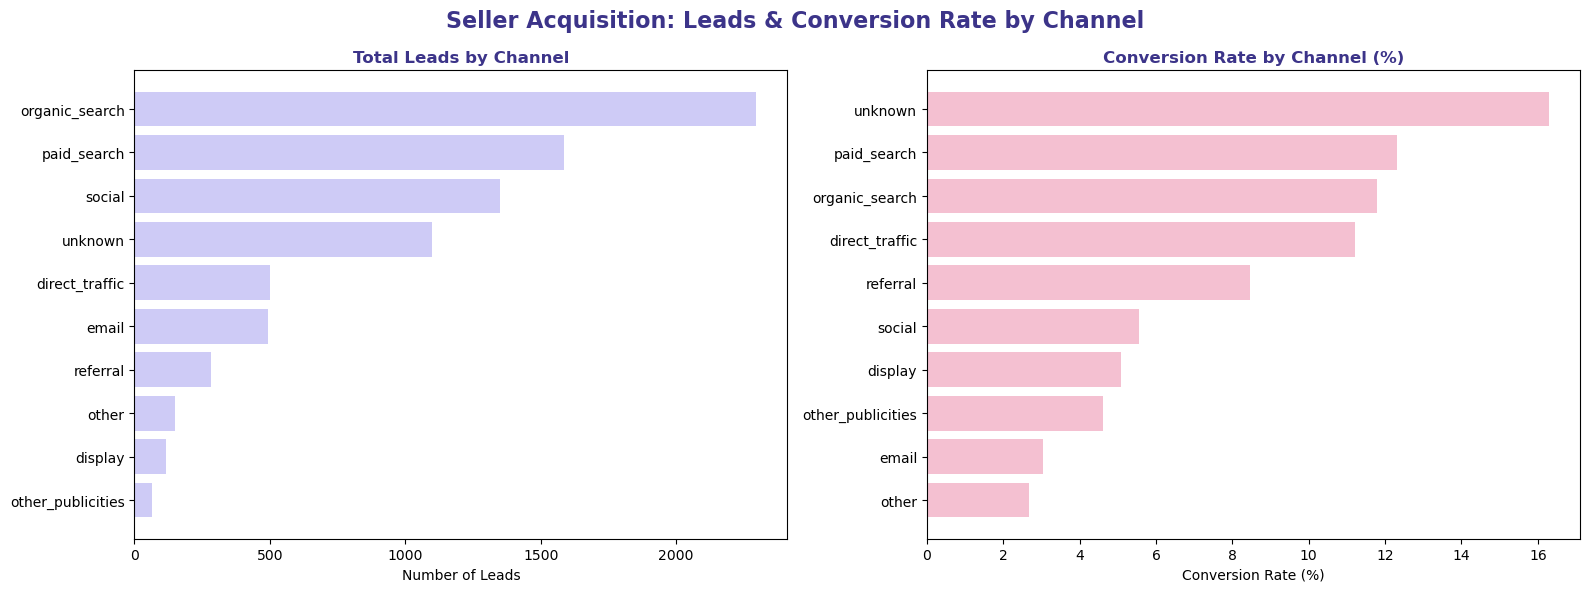

Chart saved!


In [15]:
# ================================================
# VISUALISATION — Q1 & Q2
# Leads by Channel and Conversion Rate by Channel
# ================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Seller Acquisition: Leads & Conversion Rate by Channel', 
             fontsize=16, fontweight='bold', color='#3C3489')

# Q1 — Total Leads by Channel
channel_sorted_leads = channel_analysis.sort_values('total_leads', ascending=True)
axes[0].barh(channel_sorted_leads['origin'], 
             channel_sorted_leads['total_leads'], color='#CECBF6')
axes[0].set_title('Total Leads by Channel', fontweight='bold', color='#3C3489')
axes[0].set_xlabel('Number of Leads')

# Q2 — Conversion Rate by Channel
channel_sorted_rate = channel_analysis.sort_values('conversion_rate_%', ascending=True)
axes[1].barh(channel_sorted_rate['origin'], 
             channel_sorted_rate['conversion_rate_%'], color='#F4C0D1')
axes[1].set_title('Conversion Rate by Channel (%)', fontweight='bold', color='#3C3489')
axes[1].set_xlabel('Conversion Rate (%)')

plt.tight_layout()
plt.savefig(path + 'p3_q1_q2_channel_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

---
### 11 — Visualisation: Q3 — Top Converting Business Segments

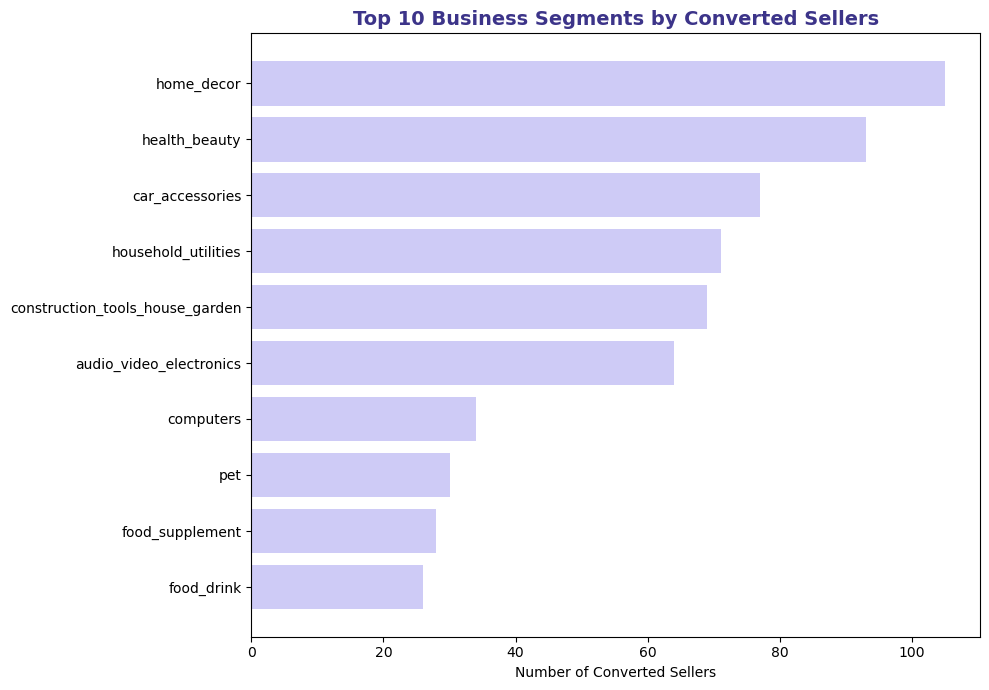

Chart saved!


In [16]:
# ================================================
# VISUALISATION — Q3
# Top Converting Business Segments
# ================================================

fig, ax = plt.subplots(figsize=(10, 7))

top10 = segment_conversion.head(10).sort_values('converted_sellers', ascending=True)

ax.barh(top10['business_segment'], top10['converted_sellers'], color='#CECBF6')
ax.set_title('Top 10 Business Segments by Converted Sellers', 
             fontsize=14, fontweight='bold', color='#3C3489')
ax.set_xlabel('Number of Converted Sellers')

plt.tight_layout()
plt.savefig(path + 'p3_q3_segment_conversion.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

---
### 12 — Visualisation: Q4 — Monthly Trend

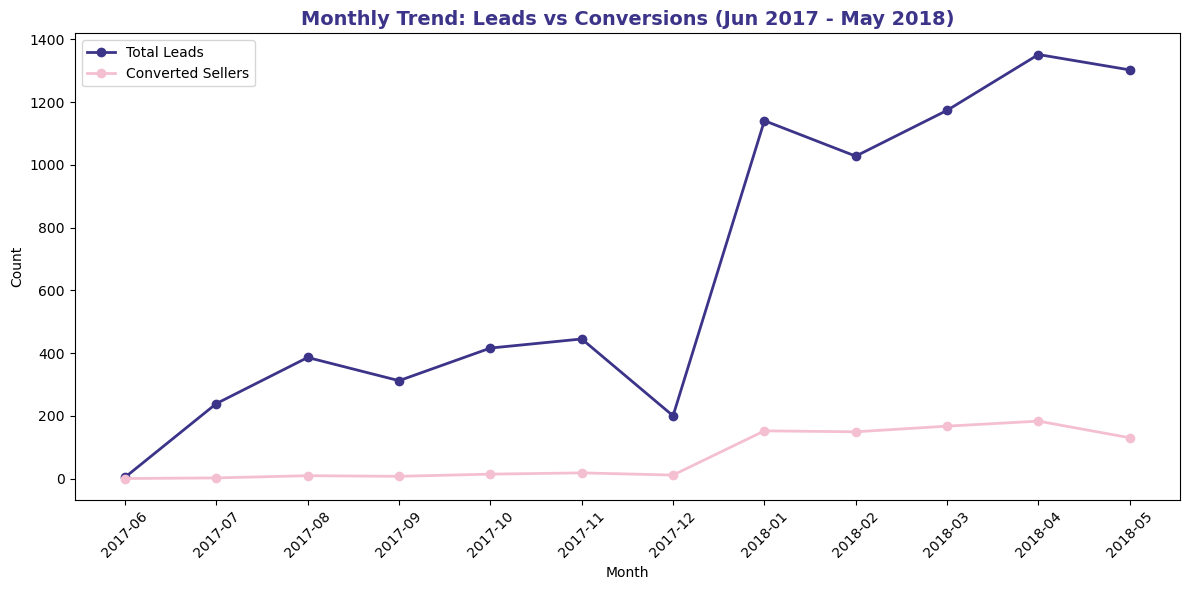

Chart saved!


In [17]:
# ================================================
# VISUALISATION — Q4
# Monthly Trend of Leads and Conversions
# ================================================

fig, ax = plt.subplots(figsize=(12, 6))

x = monthly_trend['month'].astype(str)

ax.plot(x, monthly_trend['total_leads'], 
        color='#3C3489', marker='o', linewidth=2, label='Total Leads')
ax.plot(x, monthly_trend['total_converted'], 
        color='#F4C0D1', marker='o', linewidth=2, label='Converted Sellers')

ax.set_title('Monthly Trend: Leads vs Conversions (Jun 2017 - May 2018)', 
             fontsize=14, fontweight='bold', color='#3C3489')
ax.set_xlabel('Month')
ax.set_ylabel('Count')
ax.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(path + 'p3_q4_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

--- 
### 13 — Visualisation: Q5 — Profile of Converted Sellers

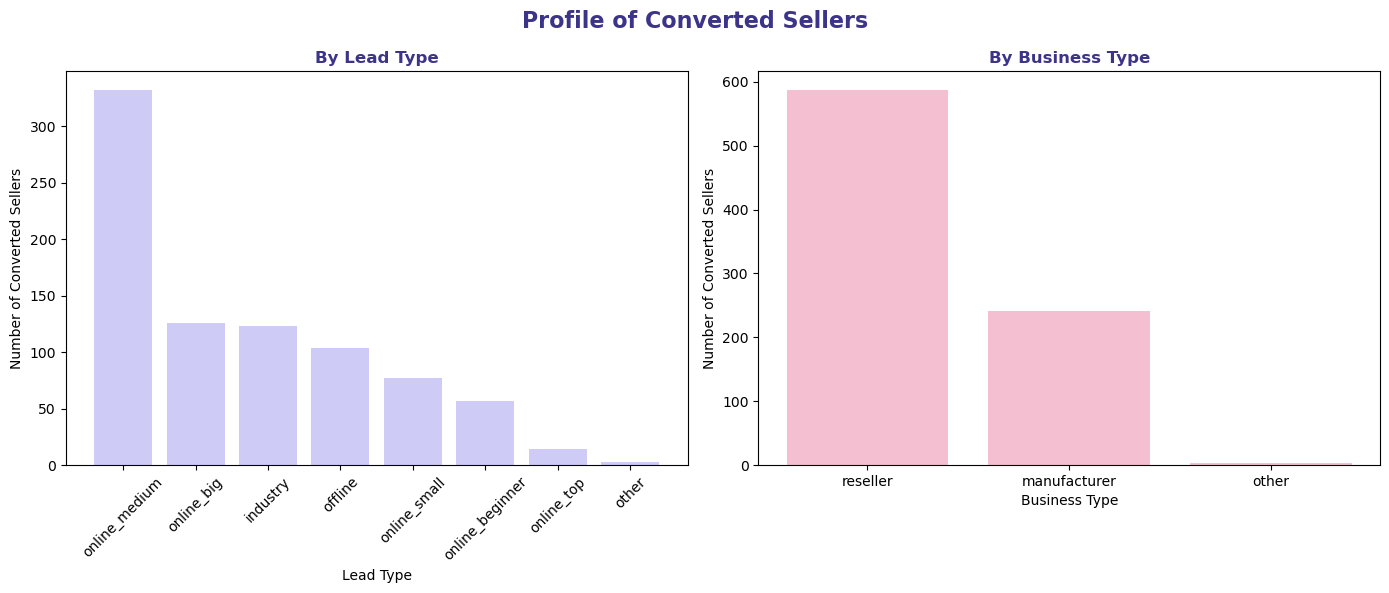

Chart saved!


In [18]:
# ================================================
# VISUALISATION — Q5
# Lead Type and Business Type Among Converted Sellers
# ================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Profile of Converted Sellers', 
             fontsize=16, fontweight='bold', color='#3C3489')

# Q5a — Lead Type
lead_type_data = funnel[funnel['converted'] == 1]['lead_type'].value_counts()
axes[0].bar(lead_type_data.index, lead_type_data.values, color='#CECBF6')
axes[0].set_title('By Lead Type', fontweight='bold', color='#3C3489')
axes[0].set_xlabel('Lead Type')
axes[0].set_ylabel('Number of Converted Sellers')
axes[0].tick_params(axis='x', rotation=45)

# Q5b — Business Type
business_type_data = funnel[funnel['converted'] == 1]['business_type'].value_counts()
axes[1].bar(business_type_data.index, business_type_data.values, color='#F4C0D1')
axes[1].set_title('By Business Type', fontweight='bold', color='#3C3489')
axes[1].set_xlabel('Business Type')
axes[1].set_ylabel('Number of Converted Sellers')

plt.tight_layout()
plt.savefig(path + 'p3_q5_seller_profile.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")